In [ ]:
from google.colab import drive
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

# Google drive mount (it is only needed once, but it is better to include it)
drive.mount('/content/drive')
print("Google Drive connected sucessfully. Everything is ready for a Patient-level split.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected sucessfully. Everything is ready for a Patient-level split.


In [ ]:
!cp -r "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification" "/content/dataset_original_local"

In [ ]:
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

def get_patient_id(filename):
    """
    Extracts a unique patient ID from the filename.
    Assumes format like: SOB_B_A-14-22549AB-40-001.png -> '14-22549AB'
    """
    parts = filename.split('-')
    if len(parts) >= 3:
        return f"{parts[1]}-{parts[2]}"
    return filename

def process_dataset_patient_split_multiclass(origin_path, final_path='/content/data_split', train_size=0.8, seed=42):
    random.seed(seed)
    origin = Path(origin_path)
    final_p = Path(final_path)

    if final_p.exists():
        print(f"Erasing old directory '{final_p}'...")
        shutil.rmtree(final_p)

    # 1. Detect zoom folders (100X, 200X, 400X, 40X)
    zooms = [f.name for f in origin.iterdir() if f.is_dir()]
    print(f"Detected zooms: {zooms}\n")

    extensions = ('*.png', '*.jpg', '*.jpeg', '*.tiff', '*.bmp')
    total_train, total_test = 0, 0

    for amp in zooms:
        # Detect the 8 tumor classes dynamically
        classes = [d.name for d in (origin / amp).iterdir() if d.is_dir()]

        # Dictionary to store all patients per class
        patients_dict = {c: {} for c in classes}

        # Group images by patient ID for each class
        for c in classes:
            for ext in extensions:
                for img in (origin / amp / c).glob(ext):
                    p_id = get_patient_id(img.name)
                    if p_id not in patients_dict[c]:
                        patients_dict[c][p_id] = []
                    patients_dict[c][p_id].append(img)

        # Skip if directory is empty or classes are missing
        if not classes or any(not patients_dict[c] for c in classes):
            print(f"Skipping zoom {amp} due to missing data.")
            continue

        # 2. Process and split each class (WITHOUT subsampling)
        amp_train_count, amp_test_count = 0, 0

        for c in classes:
            # Get ALL patients for the current class
            all_patients = list(patients_dict[c].keys())

            # Split patients (not images) into Train and Test
            # If a class only has 1 patient, force it into Train to avoid errors in sklearn
            if len(all_patients) == 1:
                train_p = all_patients
                test_p = []
            else:
                train_p, test_p = train_test_split(all_patients, train_size=train_size, random_state=seed)

            # Create hermetic destination folders
            train_dest = final_p / 'train' / c
            test_dest = final_p / 'test' / c
            train_dest.mkdir(parents=True, exist_ok=True)
            test_dest.mkdir(parents=True, exist_ok=True)

            # Copy files adding zoom prefix to avoid name collisions
            for p_id in train_p:
                for img in patients_dict[c][p_id]:
                    shutil.copy(img, train_dest / f"{amp}_{img.name}")
                    amp_train_count += 1

            for p_id in test_p:
                for img in patients_dict[c][p_id]:
                    shutil.copy(img, test_dest / f"{amp}_{img.name}")
                    amp_test_count += 1

        print(f" Zoom {amp} processed (Multiclass Patient-Level Split - All Data):")
        print(f"   - Images added to TRAIN: {amp_train_count}")
        print(f"   - Images added to TEST : {amp_test_count}\n")

        total_train += amp_train_count
        total_test += amp_test_count

    print("-" * 50)
    print("The multiclass patient-level split has finished successfully.")
    print(f"New clean data stored in: '{final_path}/'")
    print(f"Total images in TRAIN: {total_train}")
    print(f"Total images in TEST: {total_test}")

# =====================================================================
# EXECUTION
# =====================================================================
# READING FROM LOCAL COLAB DISK TO AVOID DRIVE BOTTLENECK
source_path = '/content/dataset_original_local'
local_dest_path = '/content/data_split'

process_dataset_patient_split_multiclass(origin_path=source_path, final_path=local_dest_path)

Erasing old directory '/content/data_split'...
Detected zooms: ['200X', '40X', '400X', '100X']

 Zoom 200X processed (Multiclass Patient-Level Split - All Data):
   - Images added to TRAIN: 1579
   - Images added to TEST : 434

 Zoom 40X processed (Multiclass Patient-Level Split - All Data):
   - Images added to TRAIN: 1505
   - Images added to TEST : 490

 Zoom 400X processed (Multiclass Patient-Level Split - All Data):
   - Images added to TRAIN: 1319
   - Images added to TEST : 501

 Zoom 100X processed (Multiclass Patient-Level Split - All Data):
   - Images added to TRAIN: 1485
   - Images added to TEST : 596

--------------------------------------------------
The multiclass patient-level split has finished successfully.
New clean data stored in: '/content/data_split/'
Total images in TRAIN: 5888
Total images in TEST: 2021


The first model to train is a CNN using ResNet18 without data augmentation.

1. Dataloaders

In [ ]:
import torch
import numpy as np
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, WeightedRandomSampler

# Strict preprocessing (NO Data Augmentation for the clean baseline)
transform_no_da = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load data from the new multiclass patient-split folders
train_dataset = datasets.ImageFolder(root='/content/data_split/train', transform=transform_no_da)
test_dataset = datasets.ImageFolder(root='/content/data_split/test', transform=transform_no_da)

# --- NEW: WeightedRandomSampler Configuration ---
# 1. Count the number of images per class in the training set
class_counts = np.bincount(train_dataset.targets)

# 2. Calculate the weight for each class (inversely proportional to its frequency)
class_weights = 1.0 / class_counts

# 3. Assign the corresponding weight to each individual image in the dataset
sample_weights = np.array([class_weights[t] for t in train_dataset.targets])
sample_weights = torch.from_numpy(sample_weights).double()

# 4. Create the sampler with replacement to allow repetition of minority class images
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
# ----------------------------------------------------

# DataLoaders (keeping batch_size=32)
# IMPORTANT: When using a 'sampler', shuffle MUST be False (the sampler handles the mixing)
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

print(f"Total Train images: {len(train_dataset)}")
print(f"Total Test images: {len(test_dataset)}")
print(f"Detected classes: {train_dataset.class_to_idx}")

Total Train images: 5888
Total Test images: 2021
Detected classes: {'adenosis': 0, 'ductal_carcinoma': 1, 'fibroadenoma': 2, 'lobular_carcinoma': 3, 'mucinous_carcinoma': 4, 'papillary_carcinoma': 5, 'phyllodes_tumor': 6, 'tubular_adenoma': 7}


2. Initialise the CNN ResNet18 model without data augmentation

In [ ]:
import torch.nn as nn
import torch.optim as optim

# Device configuration (CUDA for cloud, MPS for Apple Silicon, fallback to CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Training on device: {device}")

# Load pre-trained ResNet18
weights = models.ResNet18_Weights.IMAGENET1K_V1
model_cnn = models.resnet18(weights=weights)

# Ensure all layers are unfrozen (for full fine-tuning)
for param in model_cnn.parameters():
    param.requires_grad = True

# Modify the final layer for MULTICLASS classification
num_ftrs = model_cnn.fc.in_features
num_classes = len(train_dataset.classes) # This will automatically be 8

# Replace the last layer
model_cnn.fc = nn.Linear(num_ftrs, num_classes)
model_cnn = model_cnn.to(device)

# Standard loss function and optimizer
# CrossEntropyLoss works perfectly for multiclass out of the box
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.0001)

print(f"ResNet18 architecture ready for {num_classes}-class classification.")

Training on device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 230MB/s]


ResNet18 architecture ready for 8-class classification.


3. Training and save phase


In [ ]:
import time
import torch
from sklearn.metrics import classification_report

NUM_EPOCHS = 15
print("Starting training for the clean experiment (Patient-Level Split)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_cnn.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model_cnn(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # ==========================================
    # VALIDATION (TEST) PHASE
    # ==========================================
    model_cnn.eval()
    running_test_loss = 0.0
    running_test_corrects = 0
    total_test = 0

    # Lists to store true labels and predictions for the final clinical report
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_cnn(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

            # Extract predictions only during the final epoch to generate the matrix metrics
            if epoch == NUM_EPOCHS - 1:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nTraining finished successfully.")

# ==========================================
# FINAL CLINICAL METRICS REPORT
# ==========================================
print("\nGenerating Detailed Performance Report per Class...")
# Dynamically extract the class names from the dataset
class_names = [train_dataset.classes[i] for i in range(num_classes)]

# Generate the report balancing precision, recall, and F1-score
report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
print("-" * 50)
print(report)
print("-" * 50)

# Save the model with a name indicating it is the clean split
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/cnn_ResNet18_no_DA_patient_split.pth"
torch.save(model_cnn.state_dict(), save_path)
print(f"Model saved as 'cnn_ResNet18_no_DA_patient_split.pth'")

Starting training for the clean experiment (Patient-Level Split)...

Epoch 1/15 (49.6s) -> Train Loss: 0.6380 | Train Acc: 0.7899 || Test Loss: 1.2460 | Test Acc: 0.5755
Epoch 2/15 (44.5s) -> Train Loss: 0.1882 | Train Acc: 0.9424 || Test Loss: 1.5615 | Test Acc: 0.5750
Epoch 3/15 (41.2s) -> Train Loss: 0.1056 | Train Acc: 0.9704 || Test Loss: 1.7046 | Test Acc: 0.5923
Epoch 4/15 (41.4s) -> Train Loss: 0.0763 | Train Acc: 0.9803 || Test Loss: 1.8172 | Test Acc: 0.5769
Epoch 5/15 (43.8s) -> Train Loss: 0.0699 | Train Acc: 0.9788 || Test Loss: 1.5149 | Test Acc: 0.6116
Epoch 6/15 (42.1s) -> Train Loss: 0.0625 | Train Acc: 0.9810 || Test Loss: 1.5790 | Test Acc: 0.6056
Epoch 7/15 (48.1s) -> Train Loss: 0.0584 | Train Acc: 0.9820 || Test Loss: 2.0668 | Test Acc: 0.5839
Epoch 8/15 (43.8s) -> Train Loss: 0.0556 | Train Acc: 0.9828 || Test Loss: 2.1045 | Test Acc: 0.5972
Epoch 9/15 (45.0s) -> Train Loss: 0.0417 | Train Acc: 0.9901 || Test Loss: 1.8266 | Test Acc: 0.6170
Epoch 10/15 (44.0s) ->

4. Graphical representation of the data

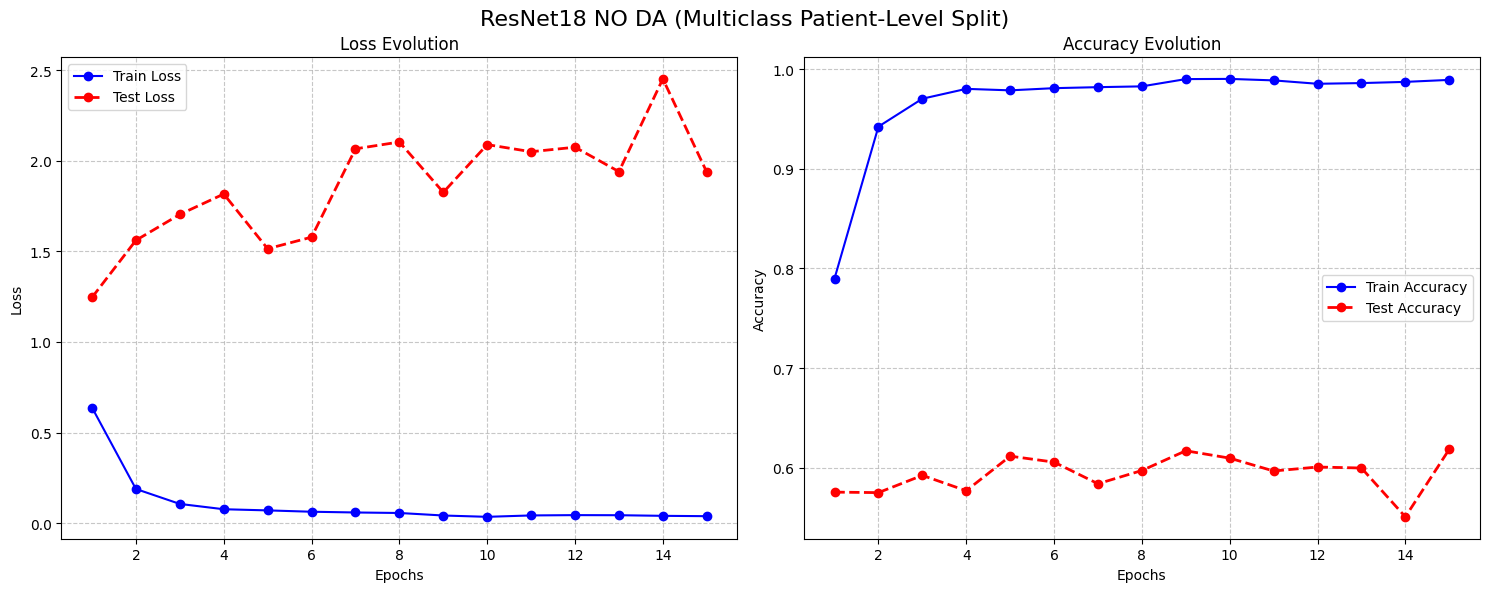

In [ ]:
import matplotlib.pyplot as plt

# 1. Data extracted from the training logs (ResNet18 WITHOUT Data Augmentation - Multiclass)
epochs = list(range(1, 16))

train_loss = [0.6380, 0.1882, 0.1056, 0.0763, 0.0699, 0.0625, 0.0584, 0.0556, 0.0417, 0.0344, 0.0421, 0.0438, 0.0433, 0.0399, 0.0380]
test_loss = [1.2460, 1.5615, 1.7046, 1.8172, 1.5149, 1.5790, 2.0668, 2.1045, 1.8266, 2.0901, 2.0508, 2.0757, 1.9409, 2.4530, 1.9382]

train_acc = [0.7899, 0.9424, 0.9704, 0.9803, 0.9788, 0.9810, 0.9820, 0.9828, 0.9901, 0.9903, 0.9888, 0.9854, 0.9861, 0.9873, 0.9893]
test_acc = [0.5755, 0.5750, 0.5923, 0.5769, 0.6116, 0.6056, 0.5839, 0.5972, 0.6170, 0.6096, 0.5967, 0.6007, 0.5997, 0.5507, 0.6185]

# 2. Figure setup (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ResNet18 NO DA (Multiclass Patient-Level Split)', fontsize=16)

# 3. Loss Evolution Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss')
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# 4. Accuracy Evolution Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy')
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# 5. Display and optionally save the figure
plt.tight_layout()
plt.subplots_adjust(top=0.9)
# plt.savefig('resnet18_multiclass_no_da_metrics.png', dpi=300) # Uncomment to save
plt.show()

5. Confusion matriz of the CNN ResNet 18 without data augmentation

In [ ]:
import numpy as np

# Calculate the exact number of images per class in the TEST set
# These numbers will perfectly match the row sums in your confusion matrix
test_counts = np.bincount(test_dataset.targets)
class_names = test_dataset.classes

print("Total images per class in the TEST set (Matrix Rows):")
print("-" * 55)
for i, count in enumerate(test_counts):
    # Format the output so the class names and numbers are neatly aligned
    print(f"{class_names[i]:>22}: {count} images")
print("-" * 55)
print(f"{'TOTAL TEST IMAGES':>22}: {sum(test_counts)} images")

Total images per class in the TEST set (Matrix Rows):
-------------------------------------------------------
              adenosis: 129 images
      ductal_carcinoma: 719 images
          fibroadenoma: 208 images
     lobular_carcinoma: 145 images
    mucinous_carcinoma: 152 images
   papillary_carcinoma: 233 images
       phyllodes_tumor: 205 images
       tubular_adenoma: 230 images
-------------------------------------------------------
     TOTAL TEST IMAGES: 2021 images


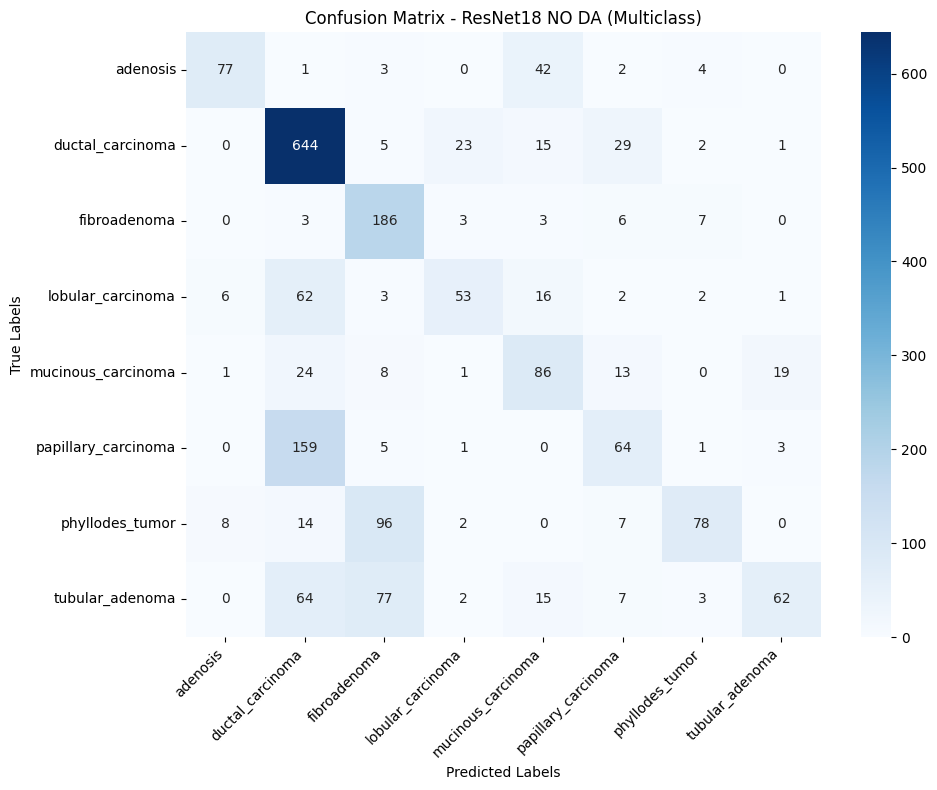

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Ensure the model is in evaluation mode
model_cnn.eval()

all_preds = []
all_labels = []

# Disable gradient calculation for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        # Move tensors to the configured device (GPU T4)
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model_cnn(inputs)
        _, preds = torch.max(outputs, 1)

        # Move predictions and true labels back to CPU to use with scikit-learn
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - ResNet18 NO DA (Multiclass)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0) # Keep y-labels horizontal for readability
plt.tight_layout()
plt.show()

Let's move on to the CNN with data augmentation:
1. Dataloaders and model initialization


In [ ]:
import torch
import numpy as np
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch.nn as nn
import torch.optim as optim
import time

# 1. Dataloaders with Data Augmentation
transform_train_da = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Test ALWAYS goes without augmentations
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_da = datasets.ImageFolder(root='/content/data_split/train', transform=transform_train_da)
test_dataset = datasets.ImageFolder(root='/content/data_split/test', transform=transform_test)

# --- NEW: WeightedRandomSampler Configuration for Imbalanced Data ---
# Count the number of images per class in the training set
class_counts = np.bincount(train_dataset_da.targets)

# Calculate the weight for each class (inversely proportional to its frequency)
class_weights = 1.0 / class_counts

# Assign the corresponding weight to each individual image in the dataset
sample_weights = np.array([class_weights[t] for t in train_dataset_da.targets])
sample_weights = torch.from_numpy(sample_weights).double()

# Create the sampler with replacement to balance the batches
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
# ------------------------------------------------------------------

# DataLoaders (keeping batch_size=32)
# IMPORTANT: shuffle MUST be False when using a sampler
train_loader_da = DataLoader(train_dataset_da, batch_size=32, sampler=sampler, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

# 2. Initialise the CNN model with data augmentation for MULTICLASS
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_cnn_da = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model_cnn_da.parameters():
    param.requires_grad = True

num_ftrs = model_cnn_da.fc.in_features
num_classes = len(train_dataset_da.classes) # Automatically detects 8 classes

# Modify for 8 classes
model_cnn_da.fc = nn.Linear(num_ftrs, num_classes)
model_cnn_da = model_cnn_da.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn_da.parameters(), lr=0.0001)

print(f"ResNet18 (with DA) architecture ready for {num_classes}-class classification.")

ResNet18 (with DA) architecture ready for 8-class classification.


2. Training, saving and givin the metrics


In [ ]:
import time
import torch
from sklearn.metrics import classification_report

NUM_EPOCHS = 15
print("Starting training for the Data Augmentation experiment (Patient-Level Split)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_cnn_da.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader_da:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model_cnn_da(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # ==========================================
    # VALIDATION (TEST) PHASE
    # ==========================================
    model_cnn_da.eval()
    running_test_loss = 0.0
    running_test_corrects = 0
    total_test = 0

    # Lists to store true labels and predictions for the final clinical report
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_cnn_da(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

            # Extract predictions only during the final epoch to generate the matrix metrics
            if epoch == NUM_EPOCHS - 1:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nTraining finished successfully.")

# ==========================================
# FINAL CLINICAL METRICS REPORT
# ==========================================
print("\nGenerating Detailed Performance Report per Class...")
# Dynamically extract the class names from the dataset
class_names = [train_dataset_da.classes[i] for i in range(num_classes)]

# Generate the report balancing precision, recall, and F1-score
report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
print("-" * 50)
print(report)
print("-" * 50)

# Save the model with a name indicating it is the DA split
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/cnn_ResNet18_DA_patient_split.pth"
torch.save(model_cnn_da.state_dict(), save_path)
print(f"Model saved as 'cnn_ResNet18_DA_patient_split.pth'")

Starting training for the Data Augmentation experiment (Patient-Level Split)...

Epoch 1/15 (51.6s) -> Train Loss: 0.1373 | Train Acc: 0.9524 || Test Loss: 2.1933 | Test Acc: 0.5631
Epoch 2/15 (51.2s) -> Train Loss: 0.1305 | Train Acc: 0.9569 || Test Loss: 2.4102 | Test Acc: 0.5868
Epoch 3/15 (52.8s) -> Train Loss: 0.1272 | Train Acc: 0.9569 || Test Loss: 2.6465 | Test Acc: 0.5903
Epoch 4/15 (50.9s) -> Train Loss: 0.0948 | Train Acc: 0.9693 || Test Loss: 2.3196 | Test Acc: 0.6056
Epoch 5/15 (51.5s) -> Train Loss: 0.1029 | Train Acc: 0.9637 || Test Loss: 2.1774 | Test Acc: 0.6066
Epoch 6/15 (51.4s) -> Train Loss: 0.1123 | Train Acc: 0.9648 || Test Loss: 2.4530 | Test Acc: 0.6170
Epoch 7/15 (51.0s) -> Train Loss: 0.0902 | Train Acc: 0.9691 || Test Loss: 2.1559 | Test Acc: 0.6190
Epoch 8/15 (52.1s) -> Train Loss: 0.0803 | Train Acc: 0.9742 || Test Loss: 2.1877 | Test Acc: 0.6195
Epoch 9/15 (51.4s) -> Train Loss: 0.0873 | Train Acc: 0.9693 || Test Loss: 2.2804 | Test Acc: 0.6210
Epoch 10/1

3. Graphical representation of the data

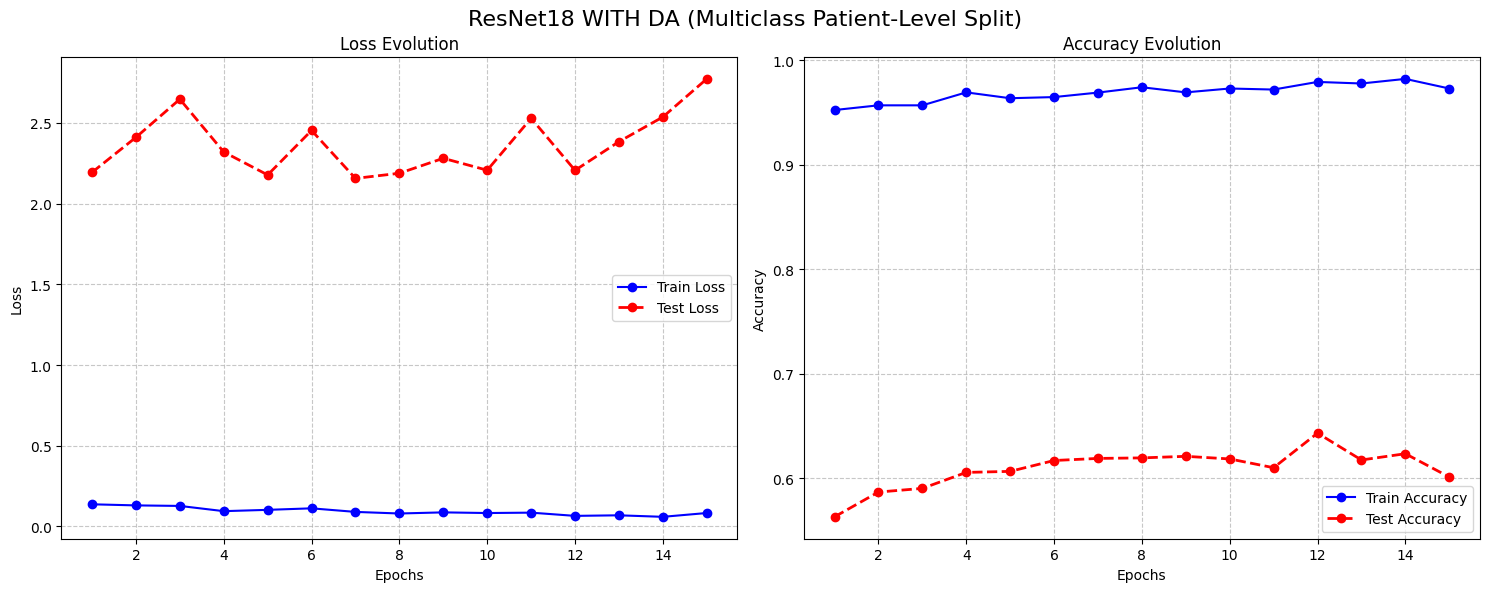

In [ ]:
import matplotlib.pyplot as plt

# 1. Data extracted from the training logs (ResNet18 WITH Data Augmentation - Multiclass)
epochs = list(range(1, 16))

train_loss = [0.1373, 0.1305, 0.1272, 0.0948, 0.1029, 0.1123, 0.0902, 0.0803, 0.0873, 0.0832, 0.0856, 0.0656, 0.0691, 0.0597, 0.0833]
test_loss = [2.1933, 2.4102, 2.6465, 2.3196, 2.1774, 2.4530, 2.1559, 2.1877, 2.2804, 2.2066, 2.5282, 2.2058, 2.3834, 2.5362, 2.7722]

train_acc = [0.9524, 0.9569, 0.9569, 0.9693, 0.9637, 0.9648, 0.9691, 0.9742, 0.9693, 0.9730, 0.9720, 0.9793, 0.9778, 0.9822, 0.9730]
test_acc = [0.5631, 0.5868, 0.5903, 0.6056, 0.6066, 0.6170, 0.6190, 0.6195, 0.6210, 0.6185, 0.6101, 0.6432, 0.6175, 0.6235, 0.6012]

# 2. Figure setup (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ResNet18 WITH DA (Multiclass Patient-Level Split)', fontsize=16)

# 3. Loss Evolution Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss')
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# 4. Accuracy Evolution Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy')
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# 5. Display and optionally save the figure
plt.tight_layout()
plt.subplots_adjust(top=0.9)
# plt.savefig('resnet18_multiclass_with_da_metrics.png', dpi=300) # Uncomment to save
plt.show()

4. Confusion matrix of the model

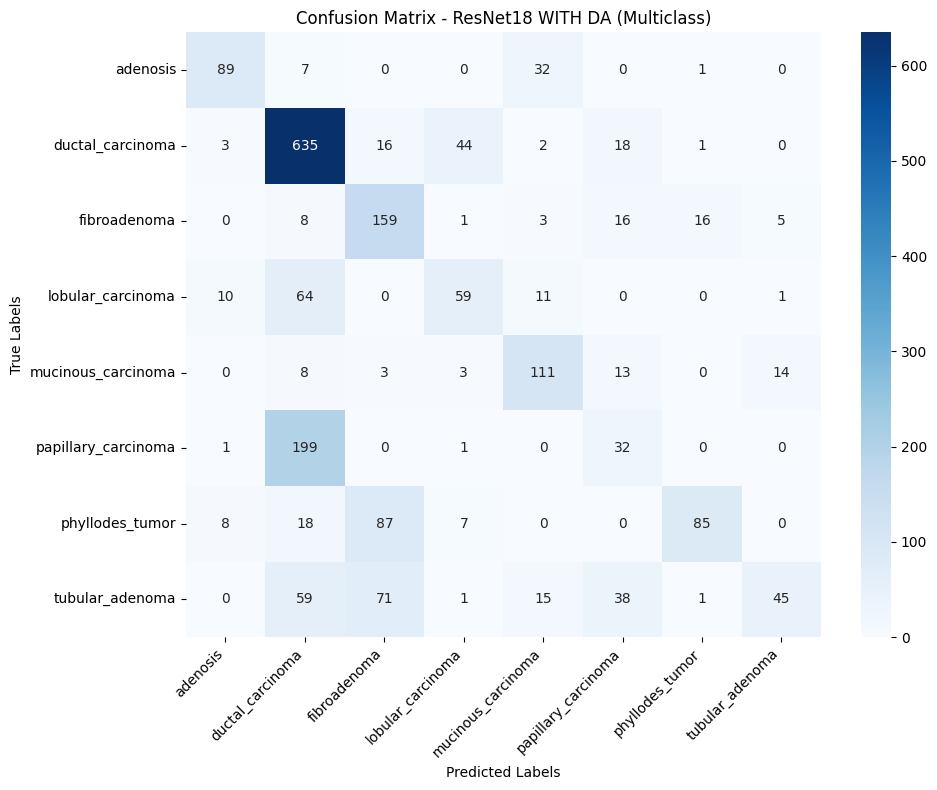

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Ensure the DA model is in evaluation mode
model_cnn_da.eval()

all_preds = []
all_labels = []

# Disable gradient calculation for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        # Move tensors to the configured device (GPU T4)
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model_cnn_da(inputs)
        _, preds = torch.max(outputs, 1)

        # Move predictions and true labels back to CPU to use with scikit-learn
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset_da.classes

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - ResNet18 WITH DA (Multiclass)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0) # Keep y-labels horizontal for readability
plt.tight_layout()
plt.show()

Model comparison:

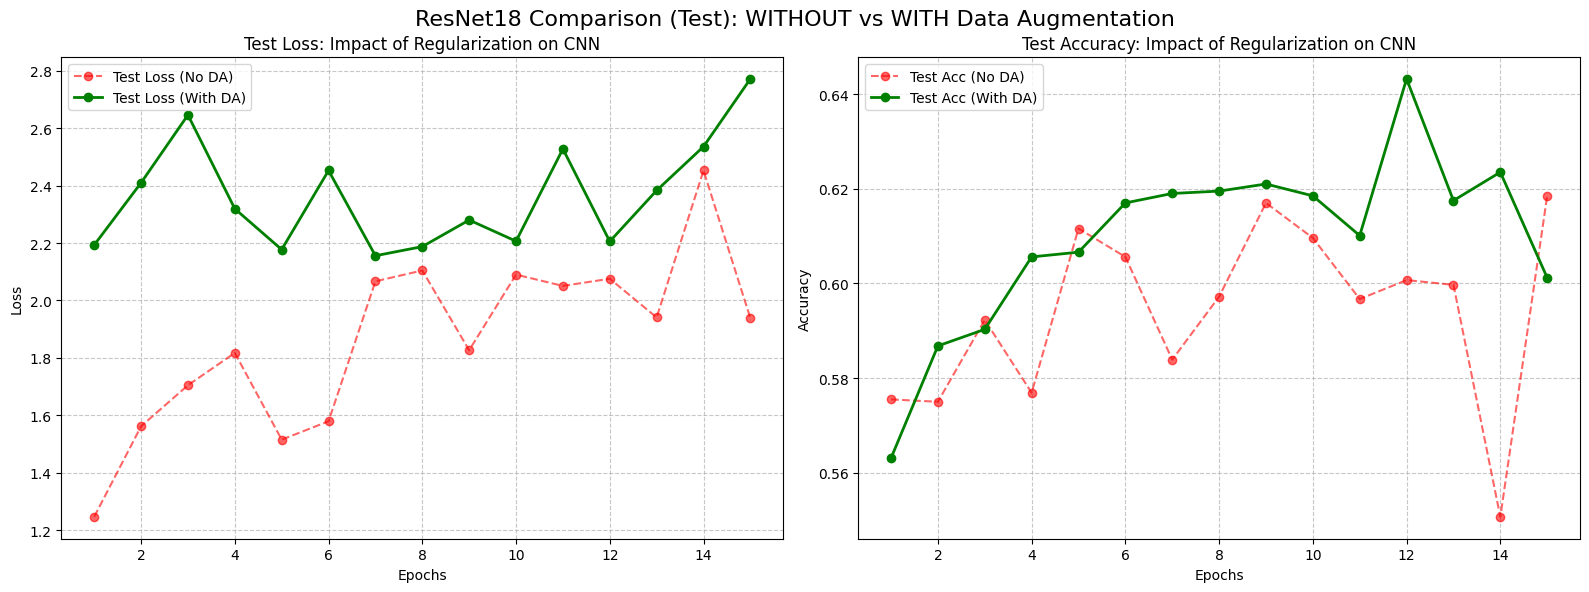

In [23]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 16))

# ResNet18 Data (Multiclass Test Metrics)
cnn_test_loss_no_da = [1.2460, 1.5615, 1.7046, 1.8172, 1.5149, 1.5790, 2.0668, 2.1045, 1.8266, 2.0901, 2.0508, 2.0757, 1.9409, 2.4530, 1.9382]
cnn_test_acc_no_da = [0.5755, 0.5750, 0.5923, 0.5769, 0.6116, 0.6056, 0.5839, 0.5972, 0.6170, 0.6096, 0.5967, 0.6007, 0.5997, 0.5507, 0.6185]

cnn_test_loss_with_da = [2.1933, 2.4102, 2.6465, 2.3196, 2.1774, 2.4530, 2.1559, 2.1877, 2.2804, 2.2066, 2.5282, 2.2058, 2.3834, 2.5362, 2.7722]
cnn_test_acc_with_da = [0.5631, 0.5868, 0.5903, 0.6056, 0.6066, 0.6170, 0.6190, 0.6195, 0.6210, 0.6185, 0.6101, 0.6432, 0.6175, 0.6235, 0.6012]

# Figure setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ResNet18 Comparison (Test): WITHOUT vs WITH Data Augmentation', fontsize=16)

# Test Loss Comparison
ax1.plot(epochs, cnn_test_loss_no_da, color='red', linestyle='--', marker='o', alpha=0.6, label='Test Loss (No DA)')
ax1.plot(epochs, cnn_test_loss_with_da, color='green', linestyle='-', marker='o', label='Test Loss (With DA)', linewidth=2)
ax1.set_title('Test Loss: Impact of Regularization on CNN')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Test Accuracy Comparison
ax2.plot(epochs, cnn_test_acc_no_da, color='red', linestyle='--', marker='o', alpha=0.6, label='Test Acc (No DA)')
ax2.plot(epochs, cnn_test_acc_with_da, color='green', linestyle='-', marker='o', label='Test Acc (With DA)', linewidth=2)
ax2.set_title('Test Accuracy: Impact of Regularization on CNN')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.9)
# plt.savefig('resnet18_da_comparison.png', dpi=300)
plt.show()

Let's move on to the ViT models, where I will train first the one without data augmentation

1. Dataloaders and initialise the model

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Load a pre-trained ViT model
# vit_b_16 is a standard base model with 16x16 patches
weights = models.ViT_B_16_Weights.IMAGENET1K_V1
model_vit = models.vit_b_16(weights=weights)

# Unfreeze all parameters (Full Fine-Tuning)
for param in model_vit.parameters():
    param.requires_grad = True

# Modify the classification head for 8 classes
# In ViT, the head is located in 'heads.head'
num_ftrs = model_vit.heads.head.in_features
num_classes = 8

model_vit.heads.head = nn.Linear(num_ftrs, num_classes)
model_vit = model_vit.to(device)

# Optimizer and Criterion remain the same as the CNN experiment
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_vit.parameters(), lr=0.0001)

print("ViT_B_16 architecture ready for 8-class classification.")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 169MB/s]


ViT_B_16 architecture ready for 8-class classification.


2. Train, save and give the metrics of the model

In [ ]:
import time
import torch
from sklearn.metrics import classification_report

# Define the number of epochs
NUM_EPOCHS = 15

print("Starting training with ViT_B_16 (Multiclass)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_vit.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    # Ensure you are using the correct loader depending on the experiment (e.g., train_loader or train_loader_da)
    for inputs, labels in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model_vit(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # ==========================================
    # VALIDATION (TEST) PHASE
    # ==========================================
    model_vit.eval()
    running_test_loss = 0.0
    running_test_corrects = 0
    total_test = 0

    # Lists to store true labels and predictions for the final clinical report
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_vit(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

            # Extract predictions only during the final epoch to generate the matrix metrics
            if epoch == NUM_EPOCHS - 1:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nTraining finished successfully.")

# ==========================================
# FINAL CLINICAL METRICS REPORT
# ==========================================
print("\nGenerating Detailed Performance Report per Class...")
# Dynamically extract the class names from the dataset (ensure train_dataset matches the loader used)
class_names = [train_dataset.classes[i] for i in range(num_classes)]

# Generate the report balancing precision, recall, and F1-score
report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
print("-" * 50)
print(report)
print("-" * 50)

# Save the model
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/vit_b_16_patient_split.pth"
torch.save(model_vit.state_dict(), save_path)
print(f"Model saved as 'vit_b_16_patient_split.pth'")

Starting training with ViT_B_16 (Multiclass)...

Epoch 1/15 (266.4s) -> Train Loss: 0.9543 | Train Acc: 0.6593 || Test Loss: 1.4490 | Test Acc: 0.5537
Epoch 2/15 (265.5s) -> Train Loss: 0.2653 | Train Acc: 0.9066 || Test Loss: 1.8118 | Test Acc: 0.6027
Epoch 3/15 (264.9s) -> Train Loss: 0.1439 | Train Acc: 0.9501 || Test Loss: 1.5855 | Test Acc: 0.5863
Epoch 4/15 (265.7s) -> Train Loss: 0.0965 | Train Acc: 0.9682 || Test Loss: 1.8931 | Test Acc: 0.5928
Epoch 5/15 (265.4s) -> Train Loss: 0.0959 | Train Acc: 0.9704 || Test Loss: 1.7195 | Test Acc: 0.5888
Epoch 6/15 (265.3s) -> Train Loss: 0.0703 | Train Acc: 0.9772 || Test Loss: 1.8603 | Test Acc: 0.6180
Epoch 7/15 (265.5s) -> Train Loss: 0.1023 | Train Acc: 0.9669 || Test Loss: 1.9219 | Test Acc: 0.6249
Epoch 8/15 (266.1s) -> Train Loss: 0.0890 | Train Acc: 0.9688 || Test Loss: 1.6249 | Test Acc: 0.6116
Epoch 9/15 (265.5s) -> Train Loss: 0.0545 | Train Acc: 0.9820 || Test Loss: 2.2961 | Test Acc: 0.5314
Epoch 10/15 (265.5s) -> Train Los

3. Graphical representation of the data

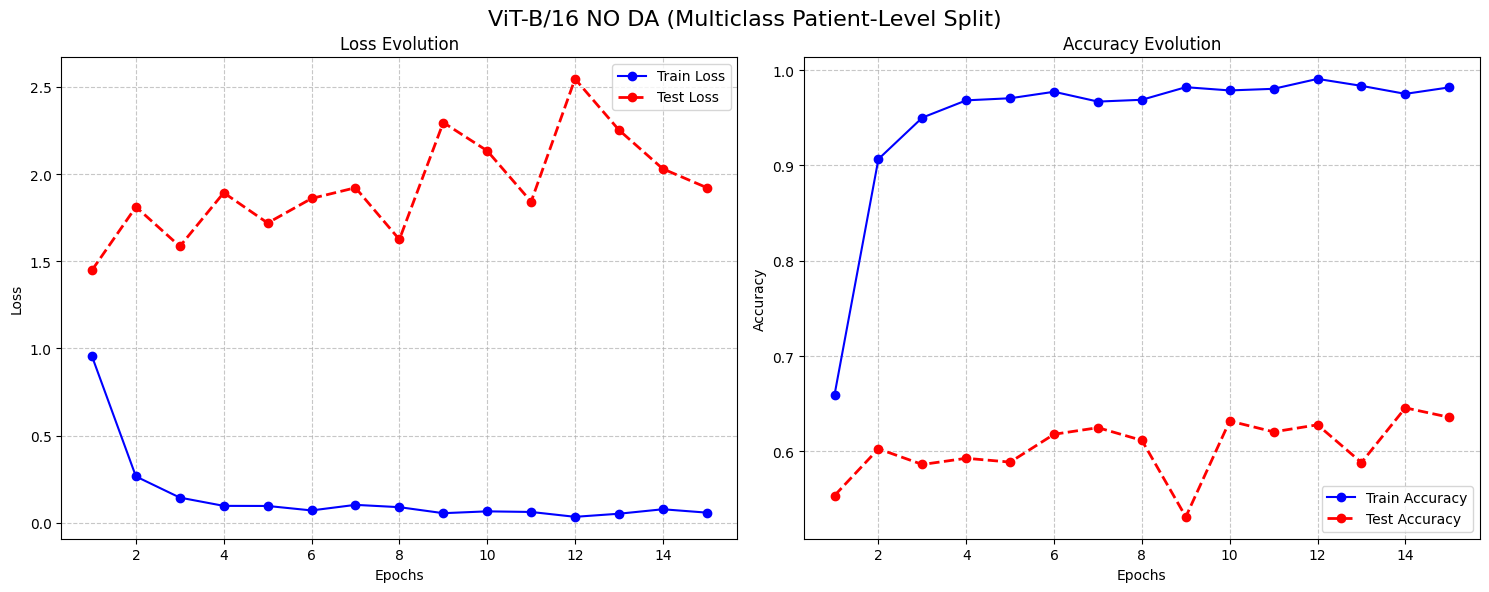

In [ ]:
import matplotlib.pyplot as plt

# 1. Data extracted from the training logs (ViT-B/16 WITHOUT Data Augmentation - Multiclass)
epochs = list(range(1, 16))

train_loss = [0.9543, 0.2653, 0.1439, 0.0965, 0.0959, 0.0703, 0.1023, 0.0890, 0.0545, 0.0650, 0.0615, 0.0336, 0.0514, 0.0770, 0.0577]
test_loss = [1.4490, 1.8118, 1.5855, 1.8931, 1.7195, 1.8603, 1.9219, 1.6249, 2.2961, 2.1338, 1.8419, 2.5464, 2.2531, 2.0302, 1.9225]

train_acc = [0.6593, 0.9066, 0.9501, 0.9682, 0.9704, 0.9772, 0.9669, 0.9688, 0.9820, 0.9786, 0.9803, 0.9907, 0.9834, 0.9750, 0.9818]
test_acc = [0.5537, 0.6027, 0.5863, 0.5928, 0.5888, 0.6180, 0.6249, 0.6116, 0.5314, 0.6319, 0.6205, 0.6279, 0.5883, 0.6457, 0.6358]

# 2. Figure setup (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ViT-B/16 NO DA (Multiclass Patient-Level Split)', fontsize=16)

# 3. Loss Evolution Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss')
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# 4. Accuracy Evolution Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy')
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# 5. Display and optionally save the figure
plt.tight_layout()
plt.subplots_adjust(top=0.9)
# plt.savefig('vit_multiclass_no_da_metrics.png', dpi=300) # Uncomment to save
plt.show()

4. Confusion matrix of the model

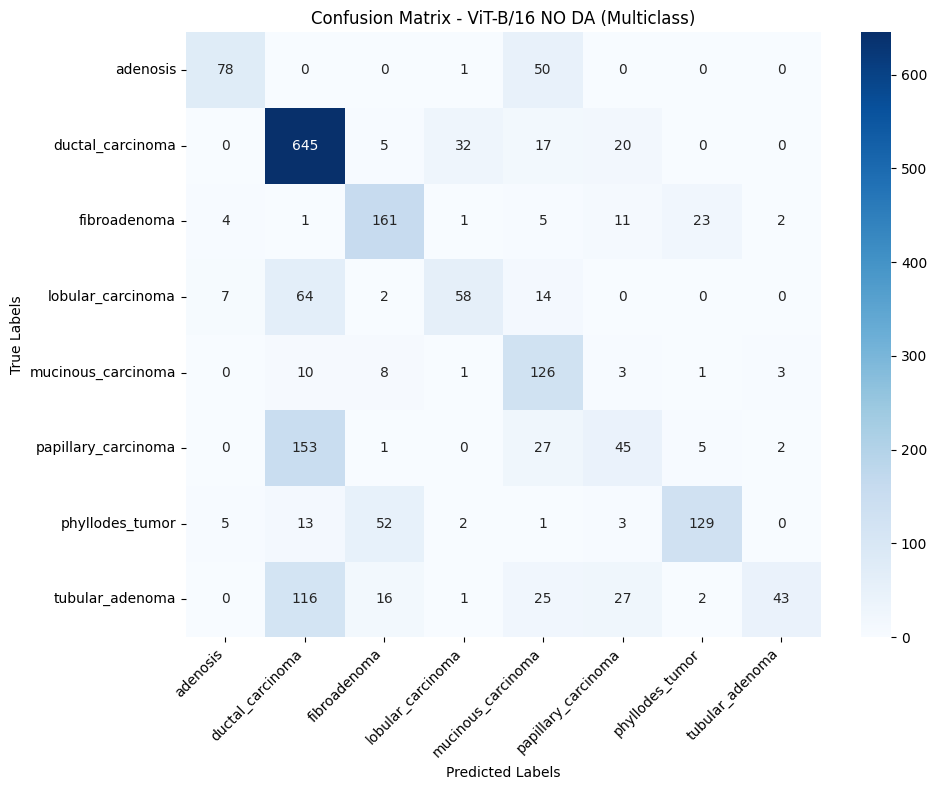

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Ensure the ViT model is in evaluation mode
model_vit.eval()

all_preds = []
all_labels = []

# Disable gradient calculation for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        # Move tensors to the configured device (GPU T4)
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model_vit(inputs)
        _, preds = torch.max(outputs, 1)

        # Move predictions and true labels back to CPU to use with scikit-learn
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - ViT-B/16 NO DA (Multiclass)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0) # Keep y-labels horizontal for readability
plt.tight_layout()
plt.show()

Let's now study the behaviour of a ViT model with data
augmentation
1. Dataloaders and initialise the model

In [ ]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, WeightedRandomSampler

# 1. Define DataLoaders with Data Augmentation
transform_train_da = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Test transformation remains standard
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset_da = datasets.ImageFolder(root='/content/data_split/train', transform=transform_train_da)
test_dataset = datasets.ImageFolder(root='/content/data_split/test', transform=transform_test)

# --- NEW: WeightedRandomSampler Configuration for Imbalanced Data ---
# Count the number of images per class in the training set
class_counts = np.bincount(train_dataset_da.targets)

# Calculate the weight for each class (inversely proportional to its frequency)
class_weights = 1.0 / class_counts

# Assign the corresponding weight to each individual image in the dataset
sample_weights = np.array([class_weights[t] for t in train_dataset_da.targets])
sample_weights = torch.from_numpy(sample_weights).double()

# Create the sampler with replacement to balance the batches
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
# ------------------------------------------------------------------

# DataLoaders
# IMPORTANT: shuffle MUST be False when using a sampler
train_loader_da = DataLoader(train_dataset_da, batch_size=32, sampler=sampler, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

# 2. Initialise the ViT model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vit_da = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# Unfreeze parameters
for param in model_vit_da.parameters():
    param.requires_grad = True

# Modify the classification head for 8 classes
num_ftrs = model_vit_da.heads.head.in_features
model_vit_da.heads.head = nn.Linear(num_ftrs, 8)
model_vit_da = model_vit_da.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_vit_da.parameters(), lr=0.0001)

print("ViT_B_16 (with DA) architecture ready.")

ViT_B_16 (with DA) architecture ready.


2. Train and save the model

In [ ]:
import time
import torch
from sklearn.metrics import classification_report

# Define the number of epochs
NUM_EPOCHS = 15

print("Starting training with ViT_B_16 (Multiclass with Data Augmentation)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_vit_da.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    # Ensure we use the Data Augmentation loader
    for inputs, labels in train_loader_da:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model_vit_da(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # ==========================================
    # VALIDATION (TEST) PHASE
    # ==========================================
    model_vit_da.eval()
    running_test_loss = 0.0
    running_test_corrects = 0
    total_test = 0

    # Lists to store true labels and predictions for the final clinical report
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_vit_da(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

            # Extract predictions only during the final epoch to generate the matrix metrics
            if epoch == NUM_EPOCHS - 1:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nTraining finished successfully.")

# ==========================================
# FINAL CLINICAL METRICS REPORT
# ==========================================
print("\nGenerating Detailed Performance Report per Class...")
# Dynamically extract the class names from the dataset
class_names = [train_dataset_da.classes[i] for i in range(8)]

# Generate the report balancing precision, recall, and F1-score
report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
print("-" * 50)
print(report)
print("-" * 50)

# Save the model
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/vit_b_16_DA_patient_split.pth"
torch.save(model_vit_da.state_dict(), save_path)
print(f"Model saved as 'vit_b_16_DA_patient_split.pth'")

Starting training with ViT_B_16 (Multiclass with Data Augmentation)...

Epoch 1/15 (278.2s) -> Train Loss: 0.8584 | Train Acc: 0.6890 || Test Loss: 1.1625 | Test Acc: 0.6200
Epoch 2/15 (277.9s) -> Train Loss: 0.3125 | Train Acc: 0.8894 || Test Loss: 1.3459 | Test Acc: 0.5992
Epoch 3/15 (276.5s) -> Train Loss: 0.2281 | Train Acc: 0.9209 || Test Loss: 1.4435 | Test Acc: 0.6155
Epoch 4/15 (277.0s) -> Train Loss: 0.1490 | Train Acc: 0.9484 || Test Loss: 1.7854 | Test Acc: 0.5913
Epoch 5/15 (277.3s) -> Train Loss: 0.1488 | Train Acc: 0.9497 || Test Loss: 1.5264 | Test Acc: 0.6363
Epoch 6/15 (277.0s) -> Train Loss: 0.1464 | Train Acc: 0.9494 || Test Loss: 1.5712 | Test Acc: 0.6517
Epoch 7/15 (276.8s) -> Train Loss: 0.0841 | Train Acc: 0.9720 || Test Loss: 1.6007 | Test Acc: 0.6259
Epoch 8/15 (277.1s) -> Train Loss: 0.0996 | Train Acc: 0.9655 || Test Loss: 1.9805 | Test Acc: 0.5992
Epoch 9/15 (276.2s) -> Train Loss: 0.1042 | Train Acc: 0.9664 || Test Loss: 1.6746 | Test Acc: 0.6517
Epoch 10/1

3. Graphical representation of the data

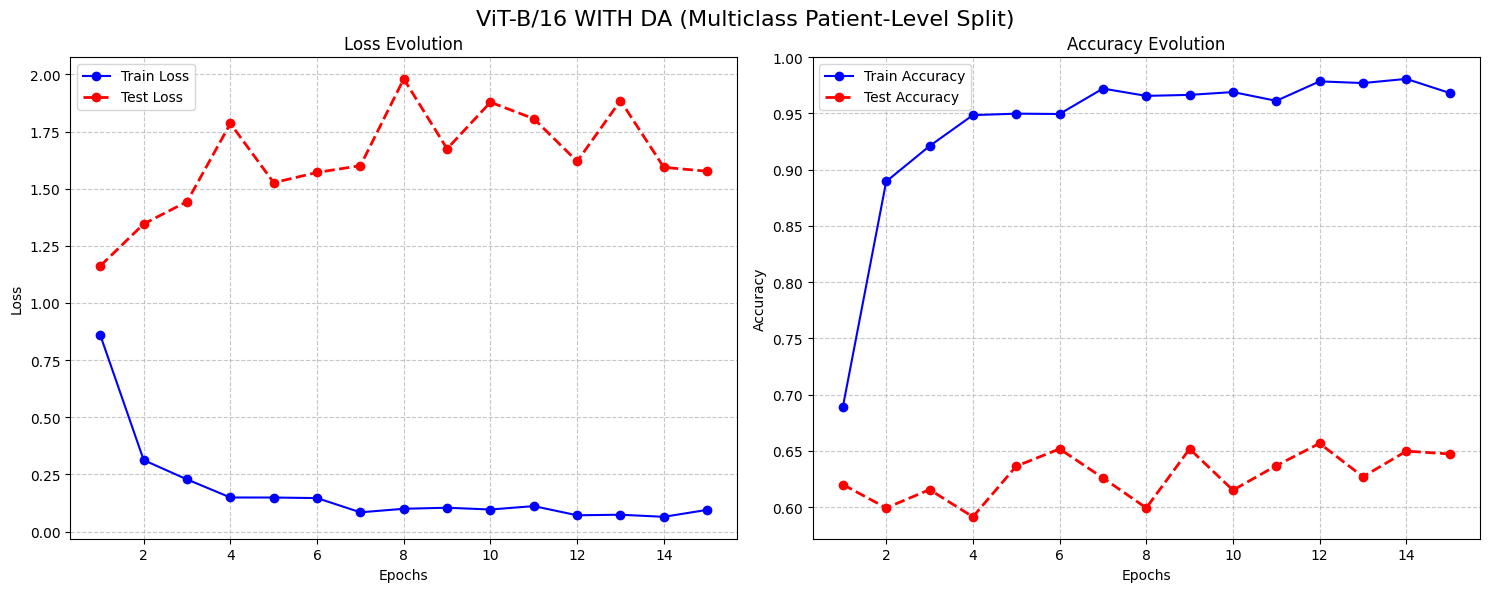

In [21]:
import matplotlib.pyplot as plt

# 1. Data extracted from the training logs (ViT-B/16 WITH Data Augmentation - Multiclass)
epochs = list(range(1, 16))

train_loss = [0.8584, 0.3125, 0.2281, 0.1490, 0.1488, 0.1464, 0.0841, 0.0996, 0.1042, 0.0964, 0.1113, 0.0712, 0.0736, 0.0644, 0.0949]
test_loss = [1.1625, 1.3459, 1.4435, 1.7854, 1.5264, 1.5712, 1.6007, 1.9805, 1.6746, 1.8784, 1.8063, 1.6196, 1.8854, 1.5937, 1.5763]

train_acc = [0.6890, 0.8894, 0.9209, 0.9484, 0.9497, 0.9494, 0.9720, 0.9655, 0.9664, 0.9689, 0.9611, 0.9784, 0.9769, 0.9806, 0.9681]
test_acc = [0.6200, 0.5992, 0.6155, 0.5913, 0.6363, 0.6517, 0.6259, 0.5992, 0.6517, 0.6150, 0.6368, 0.6566, 0.6269, 0.6497, 0.6472]

# 2. Figure setup (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ViT-B/16 WITH DA (Multiclass Patient-Level Split)', fontsize=16)

# 3. Loss Evolution Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss')
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# 4. Accuracy Evolution Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy')
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# 5. Display and optionally save the figure
plt.tight_layout()
plt.subplots_adjust(top=0.9)
# plt.savefig('vit_multiclass_with_da_metrics.png', dpi=300) # Uncomment to save
plt.show()

4. Confusion matrix

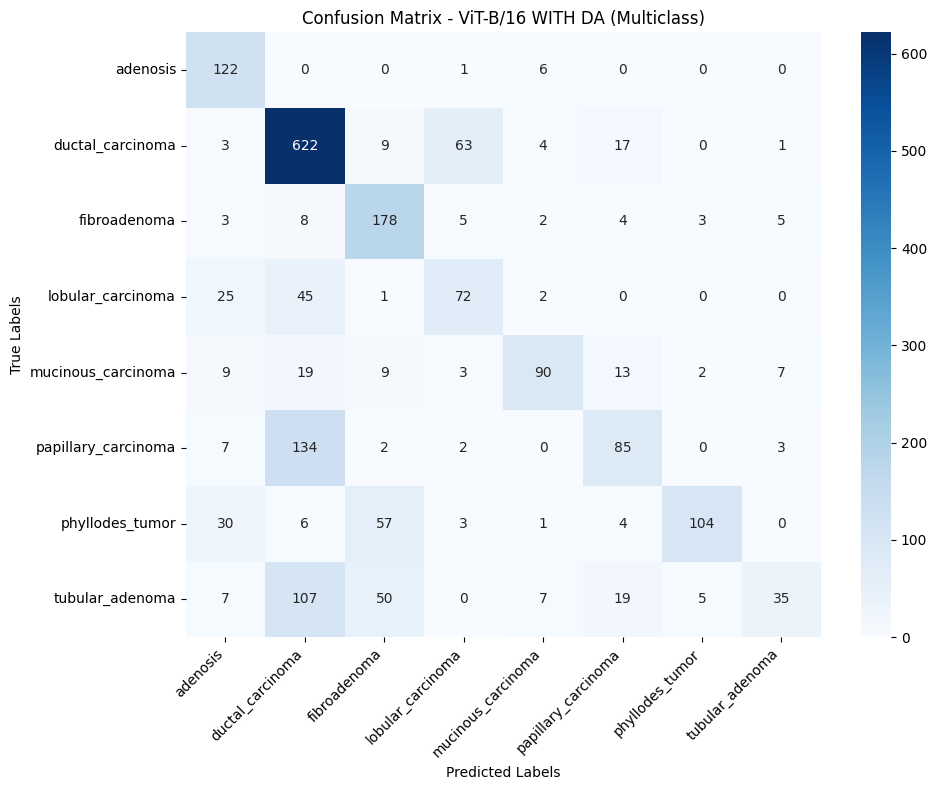

In [22]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Ensure the ViT model with DA is in evaluation mode
model_vit_da.eval()

all_preds = []
all_labels = []

# Disable gradient calculation for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        # Move tensors to the configured device (GPU T4)
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model_vit_da(inputs)
        _, preds = torch.max(outputs, 1)

        # Move predictions and true labels back to CPU to use with scikit-learn
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset_da.classes

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - ViT-B/16 WITH DA (Multiclass)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0) # Keep y-labels horizontal for readability
plt.tight_layout()
plt.show()

Model comparison:

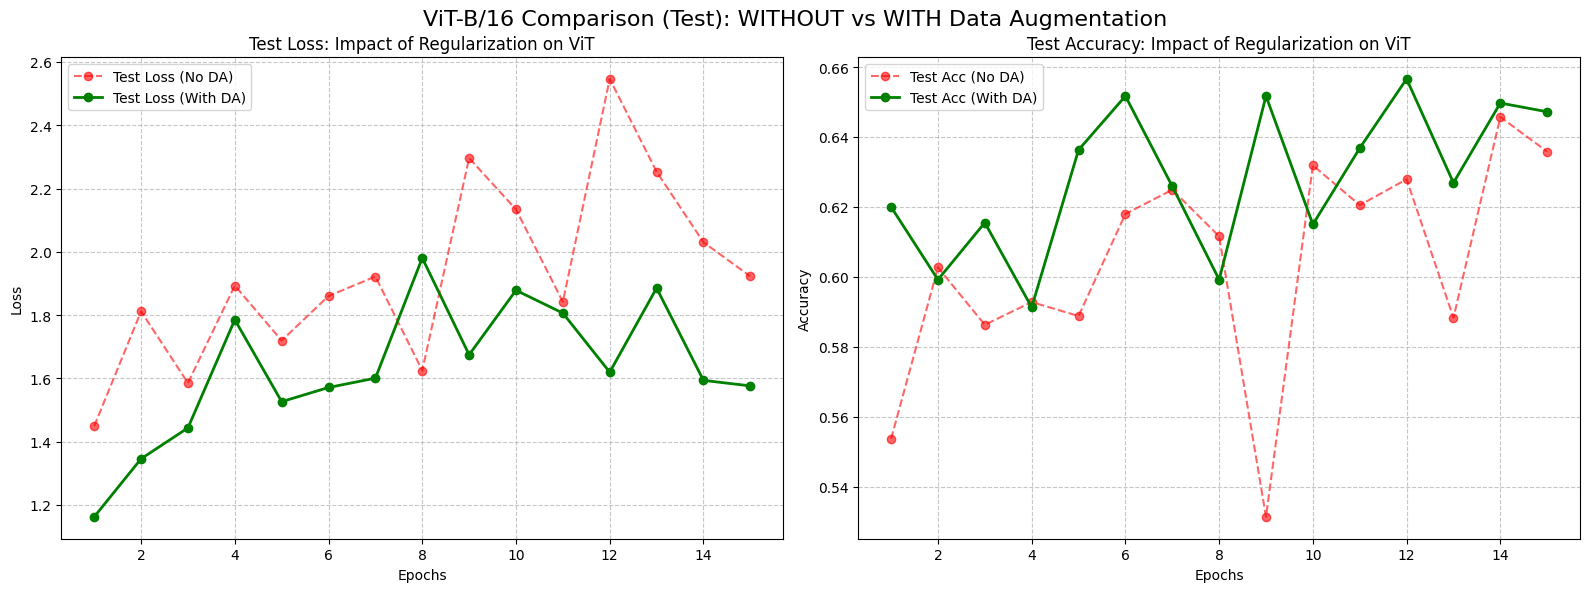

In [24]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 16))

# ViT-B/16 Data (Multiclass Test Metrics)
vit_test_loss_no_da = [1.4490, 1.8118, 1.5855, 1.8931, 1.7195, 1.8603, 1.9219, 1.6249, 2.2961, 2.1338, 1.8419, 2.5464, 2.2531, 2.0302, 1.9225]
vit_test_acc_no_da = [0.5537, 0.6027, 0.5863, 0.5928, 0.5888, 0.6180, 0.6249, 0.6116, 0.5314, 0.6319, 0.6205, 0.6279, 0.5883, 0.6457, 0.6358]

vit_test_loss_with_da = [1.1625, 1.3459, 1.4435, 1.7854, 1.5264, 1.5712, 1.6007, 1.9805, 1.6746, 1.8784, 1.8063, 1.6196, 1.8854, 1.5937, 1.5763]
vit_test_acc_with_da = [0.6200, 0.5992, 0.6155, 0.5913, 0.6363, 0.6517, 0.6259, 0.5992, 0.6517, 0.6150, 0.6368, 0.6566, 0.6269, 0.6497, 0.6472]

# Figure setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ViT-B/16 Comparison (Test): WITHOUT vs WITH Data Augmentation', fontsize=16)

# Test Loss Comparison
ax1.plot(epochs, vit_test_loss_no_da, color='red', linestyle='--', marker='o', alpha=0.6, label='Test Loss (No DA)')
ax1.plot(epochs, vit_test_loss_with_da, color='green', linestyle='-', marker='o', label='Test Loss (With DA)', linewidth=2)
ax1.set_title('Test Loss: Impact of Regularization on ViT')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Test Accuracy Comparison
ax2.plot(epochs, vit_test_acc_no_da, color='red', linestyle='--', marker='o', alpha=0.6, label='Test Acc (No DA)')
ax2.plot(epochs, vit_test_acc_with_da, color='green', linestyle='-', marker='o', label='Test Acc (With DA)', linewidth=2)
ax2.set_title('Test Accuracy: Impact of Regularization on ViT')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.9)
# plt.savefig('vit_da_comparison.png', dpi=300)
plt.show()